# Part 1. 알고리즘 · 평가지표 · ROC/AUC



---
## 0. 환경 및 데이터


### 문제 1. 환경 설정 및 titanic 전처리

- 분류 실습용 sklearn·seaborn·metrics를 준비하고, `.loc`로 결측·파생 변수를 처리합니다.


In [ ]:
import sys
# 운영체제가 macOS('darwin')가 아닐 경우 (예: 구글 코랩 등 리눅스 환경),
# 한글 출력을 위한 나눔 폰트를 설치하고 폰트 캐시를 초기화합니다.
if sys.platform != 'darwin':
    !sudo apt-get install -y -qq fonts-nanum 2>/dev/null
    !fc-cache -fv 2>/dev/null
    !rm -rf ~/.cache/matplotlib 2>/dev/null

# 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy.special import expit

# 머신러닝 모델 및 평가 지표 임포트
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay,
)
import warnings
# 불필요한 경고 메시지를 무시하도록 설정합니다.
warnings.filterwarnings('ignore')

# 나눔 폰트 파일 시스템 경로를 순회하며 matplotlib 폰트 관리자에 등록합니다.
for d in ['/usr/share/fonts/truetype/nanum', '/Library/Fonts']:
    for ff in fm.findSystemFonts(fontpaths=[d]):
        fm.fontManager.addfont(ff)

# matplotlib 및 seaborn의 기본 설정을 변경합니다 (한글 깨짐 방지, 마이너스 부호 깨짐 방지, 고해상도 설정)
plt.rcParams.update({'font.family': 'NanumBarunGothic', 'axes.unicode_minus': False, 'figure.dpi': 110})
sns.set_theme(style='whitegrid', font='NanumBarunGothic', rc={'axes.unicode_minus': False})

# 코드 실행 시 동일한 결과를 얻기 위해 난수 생성(Random Seed) 값을 고정합니다.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# 데이터셋 로드 및 전처리
# 1. seaborn 패키지에서 타이타닉 데이터셋을 불러옵니다.
titanic = sns.load_dataset('titanic')

# 2. 분석에 사용할 핵심 컬럼들만 선택하여 깊은 복사(Copy)를 수행합니다.
df = titanic.loc[:, ['survived', 'pclass', 'sex', 'age', 'fare', 'sibsp', 'parch', 'embarked']].copy()

# 3. 'age'(나이) 컬럼의 결측치(NaN)를 나이의 중앙값(Median)으로 대체합니다.
df.loc[df['age'].isnull(), 'age'] = df['age'].median()

# 4. 'embarked'(탑승 항구) 컬럼의 결측치(NaN)를 가장 빈도가 높은 최빈값(Mode)으로 대체합니다.
df.loc[df['embarked'].isnull(), 'embarked'] = df['embarked'].mode().iloc[0]

# 5. 범주형 데이터인 'sex'(성별) 컬럼을 머신러닝 모델이 이해할 수 있도록
#    여성은 1, 남성은 0의 숫자로 변환한 'sex_num' 컬럼을 새로 생성합니다.
df.loc[:, 'sex_num'] = (df['sex'] == 'female').astype(int)

# 데이터 확인 및 출력
# 전체 승객 중 생존자('survived'=1)의 비율을 계산하여 소수점 셋째 자리까지 출력합니다.
print('생존 비율:', df['survived'].mean().round(3))

# 데이터프레임의 상위 3개 행을 출력하여 데이터가 잘 정제되었는지 확인합니다.
df.head(3)

Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory det

,survived,pclass,sex,age,fare,sibsp,parch,embarked,sex_num
0,0,3,male,22.0,7.2500,1,0,S,0
1,1,1,female,38.0,71.2833,1,0,C,1
2,1,3,female,26.0,7.9250,0,0,S,1


## 1. 분류 알고리즘


### 문제 2. 로지스틱 회귀 — Sigmoid와 0.5 결정 경계
- **로지스틱 회귀**: $P(y=1|x) = \sigma(w^Tx+b) = \frac{1}{1+e^{-z}}$

- **Sigmoid** $\sigma(z)$: 실수 → (0, 1) 확률
- **결정 경계**: $P=0.5 \Leftrightarrow z=0$ (선형 경계)
- `predict_proba` ≥ 0.5 → class 1


Accuracy: 0.642


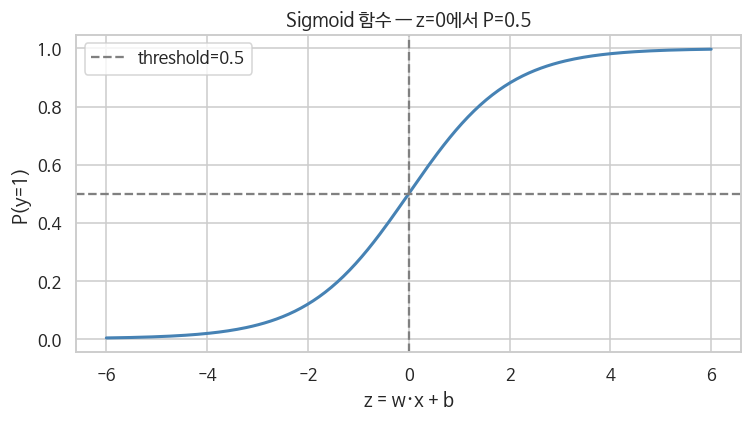

In [ ]:
# 2D 시각화용 데이터 준비: 독립변수(X2)는 나이(age)와 요금(fare)만 선택, 종속변수(y)는 생존 여부(survived)
X2 = df.loc[:, ['age', 'fare']].values
y = df.loc[:, 'survived'].values

# 학습 데이터(Train)와 테스트 데이터(Test)를 7:3 비율로 분할합니다.
# stratify=y 설정을 통해 학습/테스트 데이터의 생존자 비율을 원본과 동일하게 유지합니다.
X_tr, X_te, y_tr, y_te = train_test_split(X2, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE)

# 특성 스케일링 (표준화)
# 'age'와 'fare'의 단위(단위 크기 및 범위)가 다르므로 평균 0, 표준편차 1을 갖도록 표준화합니다.
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)  # 학습 데이터의 평균과 표준편차를 학습(fit)하고 변환(transform)
X_te_s = sc.transform(X_te)      # 테스트 데이터는 학습 데이터의 기준을 그대로 적용하여 변환

# 로지스틱 회귀 모델 객체 생성 및 학습
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_tr_s, y_tr)        # 표준화된 학습 데이터로 모델을 학습시킵니다.

# 테스트 데이터에 대한 생존 확률 예측 (클래스 1에 속할 확률 추출)
proba = log_reg.predict_proba(X_te_s)[:, 1]

# 예측 확률이 0.5 이상이면 생존(1), 아니면 사망(0)으로 분류하여 최종 정확도(Accuracy)를 계산합니다.
# 이 코드 작성
# 0.5가 진짜 최적의 분류 임곗값? 고민할 필요가 있음
# 0.6일 때, F1 score, recall, accuracy 비교 검토
# 0.7일 때, F1 score, recall, accuracy 비교 검토
accuracy = accuracy_score(y_te, (proba >= 0.5).astype(int))
print('Accuracy:', np.round(accuracy, 3))

# --- 로지스틱 회귀의 핵심인 '시그모이드(Sigmoid) 함수' 시각화 ---

# -6부터 6까지 200개의 숫자를 균등한 간격으로 생성하여 x축(z값) 데이터로 사용합니다.
z_demo = np.linspace(-6, 6, 200)

# 그래프 그리기 시작
fig, ax = plt.subplots(figsize=(7, 4))

# Scipy의 expit()을 사용하여 시그모이드 곡선을 그립니다. ( y = 1 / (1 + exp(-z)) )
ax.plot(z_demo, expit(z_demo), color='steelblue', lw=2)

# 가로 및 세로 기준선 추가 (임계값 0.5 지점 표시)
ax.axhline(0.5, color='gray', ls='--', label='threshold=0.5') # y=0.5 수평선
ax.axvline(0, color='gray', ls='--')                        # z=0 수직선

# 그래프 타이틀 및 레이블 설정
ax.set_title('Sigmoid 함수 — z=0에서 P=0.5')
ax.set_xlabel('z = w·x + b')                               # 선형 결합 결과값
ax.set_ylabel('P(y=1)')                                    # 생존(클래스 1) 확률값

ax.legend()  # 범례 표시
plt.tight_layout()
plt.show()

### 문제 3. SVM — Cortes & Vapnik (1995)

- **논문**: Cortes, C., & Vapnik, V. (1995). *Support-vector networks*. Machine Learning, 20(3), 273–297.

- **Support Vector**: **마진(margin)** 경계에 놓인 **핵심** 학습 점.
  + **Hard margin**: 선형 분리 가능, misclassification 0
  + **Soft margin**: `C`로 slack 허용 — **C↑** → hard에 가깝게(과적합 위험)

- `SVC(kernel='rbf', C=1.0)` — 비선형 경계.


In [ ]:
# RBF(방사기저함수) 커널을 사용하는 서포트 벡터 머신(SVM) 분류기 객체를 생성합니다.
# - C=1.0: 규제(Regularization) 강도를 조절합니다. (값이 클수록 오차를 덜 허용)
# - gamma='scale': RBF 커널의 영향력 범위를 결정하는 계수로, 특성 개수 기반으로 자동 설정됩니다.
# - probability=True: predict_proba()를 사용하여 확률 값을 예측할 수 있도록 설정합니다.
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE)

# 표준화된 학습 데이터로 SVM 모델을 학습시킵니다.
svm.fit(X_tr_s, y_tr)

# 테스트 데이터에 대한 예측 결과를 생성합니다.
svm_pred = svm.predict(X_te_s)

# 정확도를 계산한 뒤, 파이썬 내장 round() 함수를 사용하여 소수점 셋째 자리까지 출력합니다.
# (기존 svm.predict(...).round(3) 형태의 에러 발생 가능성을 수정)
print('SVM Accuracy:', round(accuracy_score(y_te, svm_pred), 3))

SVM Accuracy: 0.649


### 문제 4. 나이브 베이즈 — Bayes + 독립 가정

- **베이즈 정리**: $P(y|x) \propto P(y)\prod_j P(x_j|y)$
- **나이브 가정**: 특성 **조건부 독립** → 고차원에서 **빠름**.
`GaussianNB`: 연속형 $x_j$를 클래스별 **정규분포**로 모델링.


In [ ]:
# 가우시안 나이브 베이즈(Gaussian Naive Bayes) 모델 객체를 생성합니다.
# 데이터의 각 특성(Feature)이 정규분포(가우시안 분포)를 따른다고 가정하는 분류 알고리즘입니다.
gnb = GaussianNB()

# 표준화된 학습 데이터로 나이브 베이즈 모델을 학습시킵니다.
gnb.fit(X_tr_s, y_tr)

# 테스트 데이터에 대한 예측 결과를 생성합니다.
gnb_pred = gnb.predict(X_te_s)

# 정확도(Accuracy)를 계산한 뒤, 내장 round() 함수를 사용하여 소수점 셋째 자리까지 출력합니다.
# (float 객체의 에러 가능성을 원천 차단)
print('Naive Bayes Accuracy:', round(accuracy_score(y_te, gnb_pred), 3))

Naive Bayes Accuracy: 0.649


### 문제 5. KNN — 거리와 K

- **K-Nearest Neighbors**: 새 점의 **K개 이웃** 다수결.
  + **K↓** → 경계 **복잡** (과적합)
  + **K↑** → **평활** (과소적합)
  + **스케일링 필수** — 거리 기반.


In [ ]:
# K값(이웃의 수)을 3, 5, 15, 31로 바꾸어가며 KNN 모델의 성능을 비교합니다.
for k in [3, 5, 15, 31]:
    # 지정된 K값으로 K-최근접 이웃(KNN) 모델 객체를 생성합니다.
    knn = KNeighborsClassifier(n_neighbors=k)

    # 표준화된 학습 데이터로 KNN 모델을 학습시킵니다.
    knn.fit(X_tr_s, y_tr)

    # 테스트 데이터에 대한 예측 결과를 생성합니다.
    knn_pred = knn.predict(X_te_s)

    # 정확도(Accuracy)를 계산합니다.
    acc = accuracy_score(y_te, knn_pred)

    # f-string의 ':.3f' 포맷팅을 사용하면 float 객체 에러 없이
    # 안전하게 소수점 셋째 자리까지 반올림하여 출력할 수 있습니다.
    # (:2d는 이쁘게 정렬하기 위해 K값을 두 칸 차지하도록 지정한 것입니다)
    print(f'K={k:2d} Acc={acc:.3f}')

K= 3 Acc=0.627
K= 5 Acc=0.631
K=15 Acc=0.627
K=31 Acc=0.649


### 문제 6. 2D 분류 경계 — 산점도 + Contour (필수)

- age-fare 평면에 **결정 경계** 시각화.


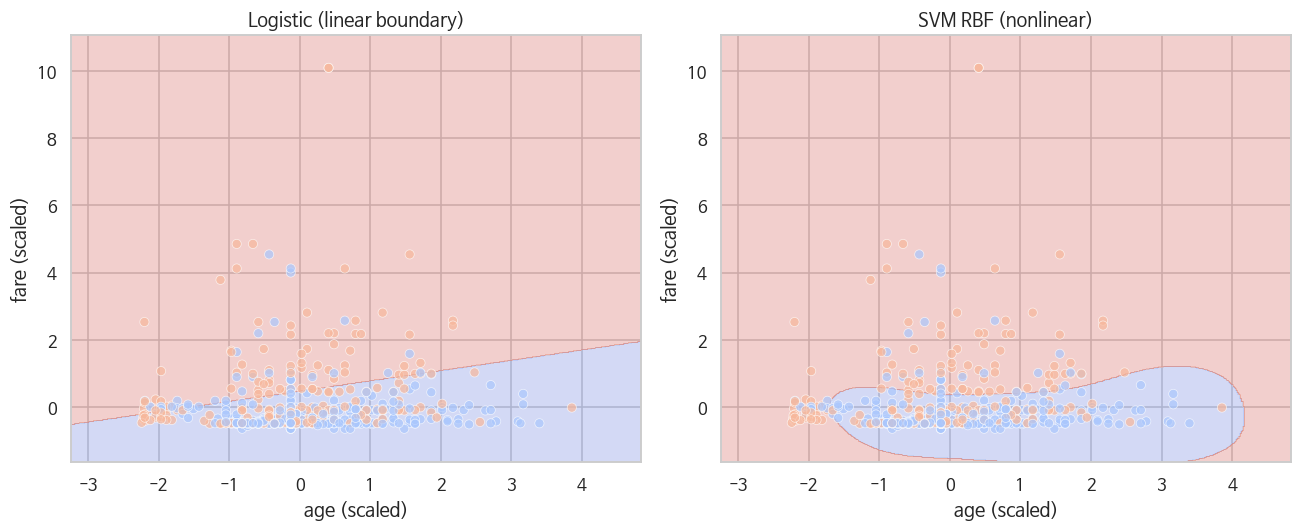

In [ ]:
def plot_boundary(clf, X, y, title, ax):
    # 그리드 격자의 간격(해상도)을 설정합니다.
    # 기존 0.5는 표준화된 데이터(-3 ~ +3 범위)에 비해 너무 커서 경계면이 각져 보일 수 있으므로
    # 0.02 정도로 촘촘하게 설정하여 부드러운 경계선을 만듭니다.
    h = 0.02

    # x축(나이)과 y축(요금)의 최솟값, 최댓값을 구해 그래프의 여백(-1, +1)을 둔 플롯 범위를 지정합니다.
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # np.meshgrid를 사용하여 격자점(Grid Points) 좌표 배열을 생성합니다.
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # 2차원 격자점들을 1차원으로 펼치고(ravel) 하나의 행렬로 합친 후(np.c_),
    # 해당 좌표들이 모델에 의해 생존(1)인지 사망(0)인지 예측(predict)합니다.
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])

    # 1차원 예측 결과를 다시 원래의 격자 형태(2차원)로 변형합니다.
    Z = Z.reshape(xx.shape)

    # ax.contourf를 이용해 모델이 예측한 클래스 영역을 색상 채우기 분할(Contour)로 표현합니다.
    # alpha=0.25로 투명도를 주어 뒤의 산점도가 잘 보이게 합니다.
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')

    # 실제 데이터셋의 샘플들을 2차원 산점도(Scatter plot)로 시각화합니다.
    # hue=y를 통해 생존 여부에 따라 색상(coolwarm)이 다르게 칠해집니다.
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='coolwarm', ax=ax, alpha=0.7, legend=False)

    # 그래프의 타이틀 및 축 이름을 설정합니다.
    ax.set_title(title)
    ax.set_xlabel('age (scaled)')
    ax.set_ylabel('fare (scaled)')

# 1행 2열 구조의 서브플롯(그래프 공간)을 생성합니다.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 첫 번째 칸(axes[0])에는 선형 결정 경계를 가진 로지스틱 회귀 모델을 시각화합니다.
plot_boundary(log_reg, X_tr_s, y_tr, 'Logistic (linear boundary)', axes[0])

# 두 번째 칸(axes[1])에는 비선형 결정 경계를 가진 SVM(RBF 커널) 모델을 시각화합니다.
plot_boundary(svm, X_tr_s, y_tr, 'SVM RBF (nonlinear)', axes[1])

# 플롯 간 여백을 자동으로 조절하고 화면에 출력합니다.
plt.tight_layout()
plt.show()

---
## 2. 평가지표 · ROC/AUC


### 문제 7. Confusion Matrix · Precision · Recall · F1

| | Pred 0 | Pred 1 |
|--|--------|--------|
| **Actual 0** | TN | FP (Type I) |
| **Actual 1** | FN (Type II) | TP |

- **Precision** = TP/(TP+FP) — "양성 예측 중 진짜"
- **Recall** = TP/(TP+FN) — "실제 양성 중 찾음"
- **F1** = 2PR/(P+R)

**실무**: **암 진단** → FN(놓침) costly → **Recall** ↑
**스팸** → FP(정상을 스팸) annoying → **Precision** ↑


#### 1. 오차 행렬 (Confusion Matrix)

오차 행렬은 모델의 예측 결과와 실제 정답이 얼마나 일치하는지(또는 헷갈리고 있는지)를 한눈에 보여주는 표입니다.

- **참 긍정 (TP, True Positive):** 실제 양성(1)을 모델이 양성(1)으로 올바르게 맞춘 경우
- **참 부정 (TN, True Negative):** 실제 음성(0)을 모델이 음성(0)으로 올바르게 맞춘 경우
- **거짓 긍정 (FP, False Positive):** 실제 음성(0)인데 모델이 양성(1)이라고 틀리게 예측한 경우 (**1종 오류**)
- **거짓 부정 (FN, False Negative):** 실제 양성(1)인데 모델이 음성(0)이라고 틀리게 예측한 경우 (**2종 오류**)

- **쉽게 외우는 팁:** > 앞 글자(**T/F**)는 예측이 '맞았는지 틀렸는지', 뒷 글자(**P/N**)는 모델이 '뭐라고 예측했는지'를 뜻합니다.
> * **FP:** 틀렸어(F), 긍정(P)이라고 예측했는데 => 실제는 음성
> * **FN:** 틀렸어(F), 부정(N)이라고 예측했는데 => 실제는 양성

- 정밀도 (Precision)

$$\text{Precision} = \frac{\text{TP}}{\text{TP} + \text{FP}}$$

  + **한글 용어:** 정밀도
  + **의미:** 모델이 **양성(1)이라고 예측한 것 중**에서, 실제 진짜 양성(1)인 데이터의 비율입니다.
  + **핵심:** 분모에 FP(틀린 양성 예측)가 들어갑니다. 즉, 확실하지 않다면 양성으로 예측하지 않아야 이 수치가 올라갑니다.

- 재현율 (Recall)

$$\text{Recall} = \frac{\text{TP}}{\text{TP} + \text{FN}}$$

  + **한글 용어:** 재현율 (또는 민감도, Sensitivity)
  + **의미:** **실제 양성(1)인 전체 데이터 중**에서, 모델이 놓치지 않고 양성(1)으로 찾아낸 비율입니다.
  + **핵심:** 분모에 FN(놓친 양성 데이터)이 들어갑니다. 즉, 긴가민가한 것도 일단 양성으로 많이 질러야(예측해야) 이 수치가 올라갑니다.

- F1-Score

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

  + **한글 용어:** F1 스코어 (또는 조화 평균)
  + **의미:** 정밀도와 재현율은 한쪽을 올리면 다른 쪽이 떨어지는 **트레이드오프(Trade-off)** 관계에 있습니다. 이 둘을 균형 있게 반영하기 위해 계산하는 **조화 평균** 값입니다.
  + **핵심:** 데이터의 클래스 비율이 불균형할 때(예: 양성이 1%, 음성이 99%), 단순 정확도(Accuracy)의 착시를 방지하기 위해 가장 신뢰하는 지표입니다.


#### 비즈니스 상황에서의 평가지표 활용

- 암 진단 및 질병 예측 => 재현율(Recall) 우선
  + **치명적인 상황:** 실제 암 환자(양성)를 건강하다(음성)고 오판하여 치료 시기를 놓치는 경우 (**FN이 치명적**)
  + **판단:** 건강한 사람에게 암이라고 오판(FP)하여 재검사를 하는 번거로움이 있을지언정, 진짜 환자를 한 명도 놓치지 않는 것(Recall ↑)이 훨씬 중요합니다.

- 스팸 메일 필터링 => 정밀도(Precision) 우선

  + **치명적인 상황:** 비즈니스에서 중요한 거래처 메일(정상, 음성)을 스팸 메일(양성)로 분류하여 휴지통에 버려지는 경우 (**FP가 치명적**)
  + **판단:** 스팸 메일 몇 개가 편지함에 노출되는 불편함(FN)이 있을지언정, 정상적인 메일을 스팸으로 차단해 버리는 대참사(Precision ↑)를 막아야 합니다.

In [ ]:
# 테스트 데이터를 바탕으로 모델의 최종 예측 클래스(0 또는 1)를 생성합니다.
y_pred = log_reg.predict(X_te_s)

# 1. 분류 평가지표 종합 리포트 출력
# '사망'(0)과 '생존'(1) 각각에 대한 Precision, Recall, F1-score, 그리고 전체 Accuracy를 한눈에 보여줍니다.
print(classification_report(y_te, y_pred, target_names=['사망', '생존']))

# 2. 오차 행렬(Confusion Matrix) 계산 및 출력
# 실제 정답(y_te)과 예측값(y_pred)을 비교하여 2x2 행렬 형태로 오차 내역을 반환합니다.
cm = confusion_matrix(y_te, y_pred)
print('CM:\n', cm)

              precision    recall  f1-score   support

          사망       0.67      0.84      0.74       165
          생존       0.56      0.33      0.41       103

    accuracy                           0.64       268
   macro avg       0.61      0.58      0.58       268
weighted avg       0.62      0.64      0.62       268

CM:
 [[138  27]
 [ 69  34]]


### 문제 8. Fawcett (2006) — Accuracy 함정 · ROC

- 관련 논문 정보

  + **논문 제목**: [An introduction to ROC analysis (Tom Fawcett, 2006)](https://doi.org/10.1016/j.patrec.2005.10.010)
  + **논문 의의**: 데이터 분류 모델을 평가할 때 단순 정확도만 보면 왜 위험한지 과학적으로 증명하고, 이를 보완할 ROC 분석 기법을 체계적으로 정리한 데이터 사이언스 분야의 명저입니다.

- 정확도의 함정 (Accuracy Paradox)

  + **다수 클래스 쏠림 현상**: 데이터의 비율이 심하게 한쪽으로 치우친 '클래스 불균형(Class Imbalance)' 환경에서는 모델이 아무런 학습 없이 무조건 양이 많은 쪽(다수 클래스)으로만 정답을 찍어도 정확도가 매우 높게 나오는 착시가 발생합니다.
  + **실무 예시 (희귀 질환 진단)**:
    - 10,000명의 환자 중 실제 환자가 10명(0.1%), 정상인이 9,990명(99.9%)인 상황이 있습니다.
    - 모델이 데이터를 전혀 보지도 않고 무조건 "모두 정상입니다!"라고 분류(예측)해 버려도 이 모델의 정확도는 99.9%가 됩니다.
  + 숫자상으로는 완벽해 보이지만, 정작 우리가 꼭 찾아내야 하는 진짜 환자 10명을 단 한 명도 찾지 못하므로 실무에서는 완전히 쓸모없는 모델입니다.

- ROC 곡선 (Receiver Operating Characteristic Curve)
  + **정의**: 분류 모델의 판정 기준값(임계값, Threshold)을 0에서 1까지 연속적으로 변화시키면서, 모델의 두 가지 지표인 거짓 긍정률(FPR)과 참 긍정률(TPR)의 변화를 평면에 그린 곡선입니다.
  + **주요 구성 지표**:
    - **참 긍정률 (TPR, True Positive Rate)**: 실제 양성(1) 중 모델이 양성으로 맞춘 비율입니다. (= 재현율)
    - **거짓 긍정률 (FPR, False Positive Rate)**: 실제 음성(0)인데 모델이 양성으로 틀리게 예측한 비율입니다. ($1 - \text{특이도}$)

- **곡선의 의미**:
  + 임계값을 낮추면 모델이 양성이라고 쉽게 지르기 때문에 실제 환자도 잘 찾지만(TPR 증가), 동시에 멀쩡한 사람을 환자로 오판할 확률(FPR 증가)도 함께 올라갑니다.
  + 좋은 모델일수록 오판(FPR)은 최소화하면서 진짜 환자(TPR)를 빠르게 찾아내므로, 곡선이 **왼쪽 위 모서리**에 가깝게 붙는 형태를 띱니다.

- AUC (Area Under the ROC Curve)

  + **정의**: ROC 곡선 아래쪽의 면적(넓이)을 의미하며, 모델의 종합적인 분류 성능을 하나의 숫자로 나타낸 지표입니다.
  + **값의 범위 및 해석**:
    - **1.0 (완벽한 분류)**: 오판 없이 모든 양성과 음성을 완벽하게 구분해 내는 상태입니다.
    - **0.5 (무작위 무차별 찍기)**: 동전 던지기처럼 아무런 분별력 없이 랜덤하게 예측하는 상태입니다. 그래프에서 대각선 직선으로 나타납니다.


- AUC는 확률의 절대적인 수치 자체보다, 모델이 "양성 샘플을 음성 샘플보다 더 높은 확률 값으로 상위에 정렬할 수 있는가?"라는 순위(Ranking) 분별력을 측정합니다.
- 따라서 임계값을 어디로 설정하든 상관없이 모델 자체의 원천적인 분류 역량을 왜곡 없이 정량화할 수 있습니다.


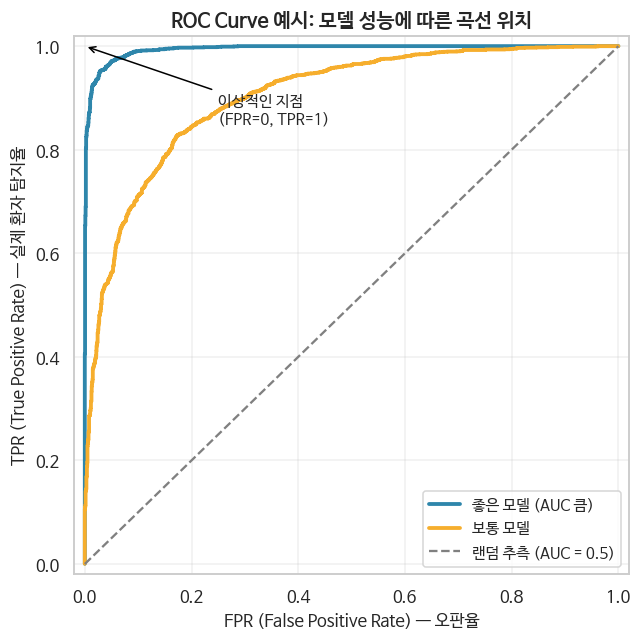

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def make_roc(auc_target, n=2000):
    # 두 그룹(양성/음성)의 점수 분포를 다르게 만들어 원하는 대략의 AUC를 흉내냄
    neg = np.random.normal(loc=0, scale=1, size=n)
    pos = np.random.normal(loc=auc_target*3, scale=1, size=n)
    scores = np.concatenate([neg, pos])
    labels = np.concatenate([np.zeros(n), np.ones(n)])

    thresholds = np.sort(scores)[::-1]
    tpr_list, fpr_list = [], []
    P = labels.sum()
    N = len(labels) - P
    for th in thresholds:
        pred = scores >= th
        tp = np.sum((pred == 1) & (labels == 1))
        fp = np.sum((pred == 1) & (labels == 0))
        tpr_list.append(tp / P)
        fpr_list.append(fp / N)
    return np.array(fpr_list), np.array(tpr_list)

fig, ax = plt.subplots(figsize=(6, 6))

# 좋은 모델 (곡선이 왼쪽 위로 붙음)
fpr_good, tpr_good = make_roc(auc_target=1.2)
ax.plot(fpr_good, tpr_good, color="#2E86AB", lw=2.5, label="좋은 모델 (AUC 큼)")

# 보통 모델
fpr_mid, tpr_mid = make_roc(auc_target=0.6)
ax.plot(fpr_mid, tpr_mid, color="#F6AE2D", lw=2.5, label="보통 모델")

# 랜덤(엉터리) 모델 - 대각선
ax.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="랜덤 추측 (AUC = 0.5)")

# 이상적인 지점 표시
ax.annotate(
    "이상적인 지점\n(FPR=0, TPR=1)",
    xy=(0, 1), xytext=(0.25, 0.85),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10, ha="left"
)

ax.set_xlabel("FPR (False Positive Rate) — 오판율", fontsize=11)
ax.set_ylabel("TPR (True Positive Rate) — 실제 환자 탐지율", fontsize=11)
ax.set_title("ROC Curve 예시: 모델 성능에 따른 곡선 위치", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 1. 항상 0(사망)으로만 예측하는 가상의 '기준 모델(Baseline)' 평가
# np.zeros_like(y_te)는 테스트 데이터(y_te)와 똑같은 크기로 모두 0(사망)이 채워진 배열을 만듭니다.
acc_dummy = accuracy_score(y_te, np.zeros_like(y_te))

# 아무런 학습 없이 0만 찍어도 타이타닉 데이터의 특성(사망자가 더 많음) 때문에
# 약 61.6%라는 제법 높은 정확도(Accuracy)의 착시가 발생하는 것을 보여줍니다.
print(f'항상 사망(0) 예측 Accuracy: {acc_dummy:.3f}')


# 2. 로지스틱 회귀 모델의 ROC 곡선 데이터 및 AUC 점수 계산
# 테스트 데이터에 대해 모델이 예측한 '생존(1) 확률값'을 추출합니다.
pred_proba_class1 = log_reg.predict_proba(X_te_s)[:, 1]

# roc_curve 함수는 다양한 임계값에 따른 거짓 긍정률(fpr)과 참 긍정률(tpr)을 계산해 줍니다.
# (세 번째 반환값인 임계값 세트는 필요하지 않아서 언더바(_)로 처리하여 버립니다)
fpr, tpr, _ = roc_curve(y_te, pred_proba_class1)

# roc_auc_score 함수를 통해 ROC 곡선 아래의 면적(AUC)을 계산합니다.
auc = roc_auc_score(y_te, pred_proba_class1)

# AUC는 항상 0만 찍는 모델의 정확도(Acc)와 달리,
# 클래스 불균형에 속지 않고 모델의 순수한 분별 성능을 0.5 ~ 1.0 사이의 값으로 정량화합니다.
print(f'Logistic AUC: {auc:.3f}')

항상 사망(0) 예측 Accuracy: 0.616
Logistic AUC: 0.666


### 문제 9. ROC Curve 시각화 (필수)


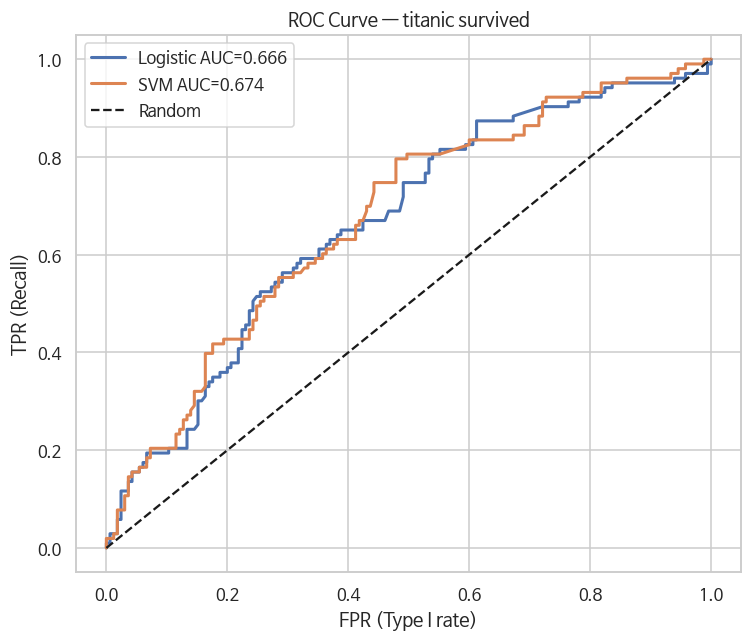

In [ ]:
# 가로 7인치, 세로 6인치 크기의 그래프 플롯 공간(Figure)을 생성합니다.
fig, ax = plt.subplots(figsize=(7, 6))

# 로지스틱 회귀와 SVM 모델을 순회하며 반복문(for)을 실행합니다.
for name, clf in [('Logistic', log_reg), ('SVM', svm)]:
    # 테스트 데이터에 대해 각 모델이 예측한 '생존(1) 확률값'을 추출합니다.
    prob = clf.predict_proba(X_te_s)[:, 1]

    # 임계값 변화에 따른 거짓 긍정률(fpr)과 참 긍정률(tpr) 데이터를 계산합니다.
    fpr, tpr, _ = roc_curve(y_te, prob)

    # 각 모델의 AUC 점수를 계산하여 라벨(label)에 포함한 뒤, ROC 곡선을 그래프에 그립니다.
    # lw=2는 선의 두께(Line Width)를 의미합니다.
    ax.plot(fpr, tpr, lw=2, label=f'{name} AUC={roc_auc_score(y_te, prob):.3f}')

# 아무런 분별력이 없는 상태(무작위 찍기, Random)를 뜻하는 기준선(대각 점선)을 추가합니다.
# 'k--'는 검은색(black) 점선(dashed line)을 의미합니다.
ax.plot([0, 1], [0, 1], 'k--', label='Random')

# x축 레이블 설정: 거짓 긍정률(FPR, 1종 오류 발생 비율)
ax.set_xlabel('FPR (Type I rate)')

# y축 레이블 설정: 참 긍정률(TPR, 실제 양성 중 찾아낸 비율인 재현율/Recall)
ax.set_ylabel('TPR (Recall)')

# 그래프의 전체 타이틀을 지정합니다.
ax.set_title('ROC Curve — titanic survived')

# 설정한 라벨들을 바탕으로 그래프 내부 한 구석에 범례(Legend)를 표시합니다.
ax.legend()

# 여백을 자동으로 조절하여 깔끔하게 다듬은 후 화면에 플롯을 출력합니다.
plt.tight_layout()
plt.show()

- 지표(AUC) 관점에서의 비교
  + **Logistic AUC**: `0.666`
  + **SVM AUC**: `0.674`

- 곡선의 형태(의미) 관점에서의 해석
  + FPR 0.0 ~ 0.2 구간 (예측 기준이 엄격할 때)
    - 그래프 왼쪽 아래를 보시면 주황색 선(SVM)이 파란색 선(Logistic)보다 **더 위쪽에 위치**해 있습니다.
    - 이는 "틀릴 확률(FPR)을 똑같이 낮게 통제하더라도, SVM이 진짜 생존자(TPR)를 더 많이 잡아낸다"는 뜻입니다.

- FPR 0.4 ~ 0.6 구간 (중간 지대)

  + 이 구간에서도 주황색 선(SVM)이 뚜렷하게 파란색 선보다 위로 툭 튀어나와 있습니다.
  + 결정 경계에 걸쳐 있는 애매한 승객들을 분류할 때, 곡선이 왼쪽 위 모서리에 더 가깝게 붙어 있는 **SVM이 더 정교하게 생존자와 사망자를 가려내고 있음**을 의미합니다.

### 문제 10. 4개 알고리즘 F1 비교 Bar



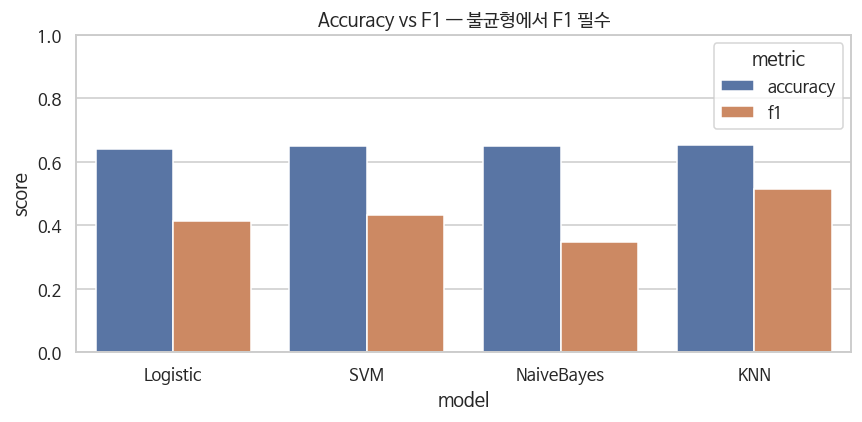

In [ ]:
# 1. 비교 분석할 4가지 모델을 딕셔너리 형태로 정의합니다.
models = {
    'Logistic': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'SVM': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
    'NaiveBayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=7),
}

# 각 모델의 성능 결과 지표를 담을 빈 리스트를 생성합니다.
rows = []

# 2. 반복문을 통해 각 모델을 순차적으로 학습시키고 평가합니다.
for name, m in models.items():
    m.fit(X_tr_s, y_tr)       # 표준화된 학습 데이터로 모델 학습
    pred = m.predict(X_te_s)  # 테스트 데이터에 대한 예측 클래스(0 또는 1) 생성

    # 모델명, 정확도(Accuracy), F1 스코어를 딕셔너리 형태로 저장하여 리스트에 추가합니다.
    # (여기서는 값 자체를 저장하므로 float 에러가 발생하지 않습니다)
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_te, pred),
        'f1': f1_score(y_te, pred)
    })

# 리스트에 담긴 결과를 판다스 데이터프레임(DataFrame)으로 변환합니다.
res = pd.DataFrame(rows)

# 3. 시각화를 위한 데이터 재구조화 (Melt 함수 사용)
# 기존 가로로 넓은 형태(Wide-form)의 데이터프레임을 Seaborn 시각화에 적합한 세로로 긴 형태(Long-form)로 녹여냅니다.
# 'accuracy'와 'f1' 컬럼이 'metric'이라는 하나의 컬럼 내부 값으로 통합됩니다.
res_m = res.melt(id_vars='model', value_vars=['accuracy', 'f1'], var_name='metric', value_name='score')

# 4. 성능 비교 막대그래프(Bar plot) 그리기
fig, ax = plt.subplots(figsize=(8, 4))

# x축은 모델명, y축은 점수(score)를 나타내며, hue='metric'을 통해 정확도와 F1 스코어가 나란히 배치됩니다.
sns.barplot(data=res_m, x='model', y='score', hue='metric', ax=ax)

ax.set_ylim(0, 1) # 점수의 범위가 0~1(0%~100%) 사이이므로 y축의 한계선을 고정합니다.
ax.set_title('Accuracy vs F1 — 불균형에서 F1 필수')

plt.tight_layout()
plt.show()